# Combined Global / Local fit for pointing recovery

In [1]:
import astropy.units as u
import jax
import jax.numpy as jnp
import numpy as np
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

from nyx.atmosphere import single_scattering
from nyx.core import Optimizer, Scene, freeze_all, unfreeze
from nyx.core.geometry import Geometry
from nyx.core.observation import Observation
from nyx.emitter import Airglow, Moon, Stars, ZodiacalLight
from nyx.instrument import EffectiveApertureMisalignmentInstrument

E0602 13:20:17.801615  761294 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0602 13:20:17.801836  761295 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0602 13:20:17.801950  761296 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


## Building model:

In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 50) * u.nm,  # wavelength grid
    nside=32,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

hess_ct1 = EffectiveApertureMisalignmentInstrument.load(
    "../../nyx/data/HESSI_with_alignment.h5", geo, batch_size=32
)

atmosphere = single_scattering.HGOzoneAbsorption(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

## Creating an example observation:

In [3]:
location = EarthLocation.from_geodetic(
    lon=16.5028 * u.deg,
    lat=-23.2728 * u.deg,
    height=1.835 * u.km,
)
times = Time("2021-06-12T02:12:16", scale="utc") + jnp.linspace(0, 15, 40) * 60 * u.s
target = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")

obs = Observation(location, times, target, geo)

## Creating target images:

In [4]:
scene = Scene.build(hess_ct1, atmosphere, sources, obs)

# Add a random pointing shift:
nshift = np.deg2rad(np.random.uniform(-0.05, 0.05, size=(scene.nobs["instrument"], 2)))
scene = scene.set("instrument.shift", jnp.array(nshift))

# Add realistic psf values:
sigma_x, sigma_y = 13.0, 18.0
scene = scene.set("instrument.sigma_x", sigma_x)
scene = scene.set("instrument.sigma_y", sigma_y)

# Add a random flatfielding offset:
pix_efficiency_shift = np.random.lognormal(
    mean=0, sigma=0.1, size=scene.instrument.pixel_efficiency.value.shape
)
scene = scene.set("instrument.pixel_efficiency", jnp.array(pix_efficiency_shift))

In [5]:
rates = scene.render()["instrument"]

rel_error = 0.05  # 5% relative error seems realistic from HMC of flatfielded data
N = 1 / (2 * rel_error**2)
truth_images = rates * np.sqrt(np.random.chisquare(df=N, size=rates.shape) / N)

## Initializing clean scene again:

In [6]:
sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

scene = Scene.build(hess_ct1, atmosphere, sources, obs)

# Add realistic psf start values:
scene = scene.set("instrument.sigma_x", 20.0)
scene = scene.set("instrument.sigma_y", 20.0)

## Creating a loss function:

Fitting without sigma_x/sigma_y first:

In [7]:
%%time
import optimistix as optx

# First pass: all instrument components trainable except sigma_x / sigma_y.
scene = freeze_all(scene)
scene = unfreeze(
    scene,
    lambda s: s.instruments["instrument"].shift,
    lambda s: s.instruments["instrument"].rotation,
    lambda s: s.instruments["instrument"].pixel_efficiency,
)


def residuals_fn(scene):
    preds = scene.render()["instrument"]
    return (preds - truth_images) / (preds * rel_error)


opt = Optimizer(residuals_fn, optx.LBFGS(rtol=1e-5, atol=1e-5))
fitted, sol = opt.run(scene, max_steps=1024)
print(
    jnp.sum(residuals_fn(fitted) ** 2) / scene.nobs["instrument"],
    sol.result,
    int(sol.stats["num_steps"]),
)

939.2578 optimistix._solution.RESULTS<> 91
CPU times: user 28.4 s, sys: 1.67 s, total: 30.1 s
Wall time: 27.5 s


# Scanning loss surface:

In [8]:
@jax.jit
def scan_chi2_sigma(sx, sy):
    perturbed = fitted.set("instrument.sigma_x", sx)
    perturbed = perturbed.set("instrument.sigma_y", sy)

    nu_fit, sol = opt.run(perturbed, max_steps=1024)
    return jnp.sum(residuals_fn(nu_fit) ** 2)

In [9]:
%%time
n = 10
sigx_range = np.linspace(sigma_x - 5.0, sigma_x + 5.0, n)
sigy_range = np.linspace(sigma_y - 5.0, sigma_y + 5.0, n)

chi2_grid = np.zeros((n, n))

for i, sx in enumerate(sigx_range):
    print(i)
    for j, sy in enumerate(sigy_range):
        chi2_grid[j, i] = scan_chi2_sigma(sx, sy)

0
1
2
3
4
5
6
7
8
9
CPU times: user 3min 13s, sys: 1.82 s, total: 3min 15s
Wall time: 3min 11s


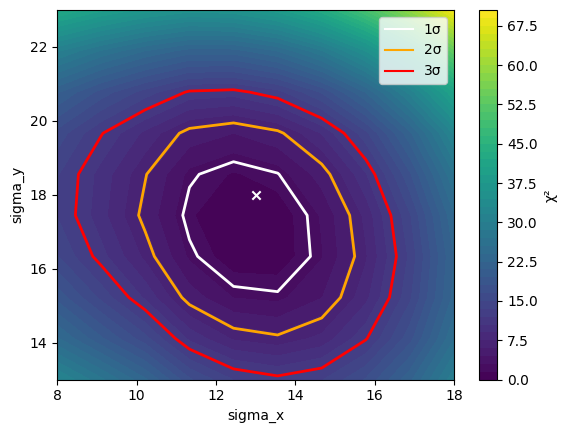

In [10]:
import matplotlib.pyplot as plt

chi2_min = chi2_grid.min()

fig, ax = plt.subplots()
c = ax.contourf(sigx_range, sigy_range, chi2_grid - chi2_min, levels=50)
ax.contour(
    sigx_range,
    sigy_range,
    chi2_grid - chi2_min,
    levels=[2.30, 6.18, 11.83],
    colors=["white", "orange", "red"],
    linewidths=2,
    linestyles="solid",
)
ax.set_xlabel("sigma_x")
ax.set_ylabel("sigma_y")
fig.colorbar(c, label="χ²")
ax.legend(
    handles=[
        plt.Line2D([], [], color="white", label="1σ"),
        plt.Line2D([], [], color="orange", label="2σ"),
        plt.Line2D([], [], color="red", label="3σ"),
    ]
)

plt.scatter(float(sigma_x), float(sigma_y), color="white", marker="x")